In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## Loading data

In [3]:
card_df = pd.read_csv('creditcard.csv')
card_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
card_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Class
0    284315
1       492
Name: count, dtype: int64


<Axes: xlabel='Class', ylabel='count'>

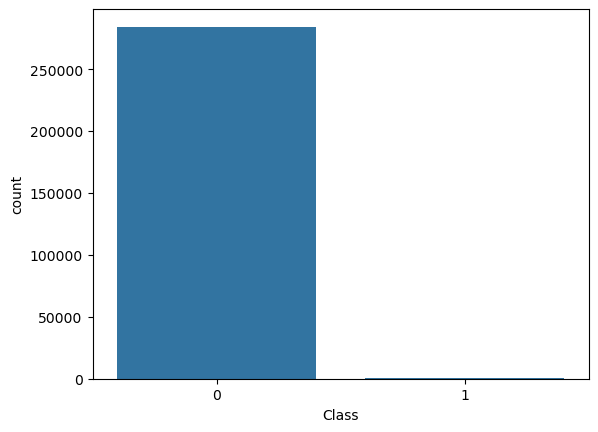

In [5]:
print(card_df['Class'].value_counts())
sns.countplot(x=card_df["Class"], data=card_df)

## Splitting the data

In [6]:
X = card_df.drop(['Class'], axis=1)
Y = card_df['Class']

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

## 1. Training the model using Logistic Regression

In [8]:
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_train, Y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## Model evaluation

In [9]:
y_pred = lr.predict(X_test)
score = accuracy_score(y_pred, Y_test)
print("Accuracy Score:", score)
print(confusion_matrix(Y_test, y_pred))
print(classification_report(Y_test, y_pred, digits=4))

Accuracy Score: 0.9704188757417226
[[55187  1677]
 [    8    90]]
              precision    recall  f1-score   support

           0     0.9999    0.9705    0.9850     56864
           1     0.0509    0.9184    0.0965        98

    accuracy                         0.9704     56962
   macro avg     0.5254    0.9444    0.5407     56962
weighted avg     0.9982    0.9704    0.9834     56962



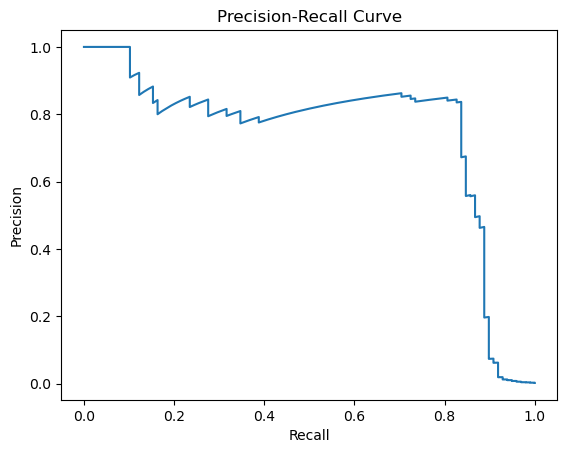

In [10]:
y_scores = lr.decision_function(X_test)  # or predict_proba for probability
precisions, recalls, thresholds = precision_recall_curve(Y_test, y_scores)

plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

## 2. Using SMOTE to oversample fraud cases

In [11]:
from imblearn.over_sampling import SMOTE

In [12]:
X = card_df.drop(['Class'], axis=1)
Y = card_df['Class']

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

In [14]:
# Applying SMOTE on training data only
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, Y_train)

print("Before SMOTE:", Y_train.value_counts())
print("After SMOTE:", pd.Series(y_res).value_counts())

Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


In [15]:
# Training the model (Logistic Regression)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_res, y_res)

LogisticRegression(max_iter=1000, random_state=42)

In [16]:
# Evaluating model on test data
y_pred = lr.predict(X_test)
score = accuracy_score(y_pred, Y_test)
print("Accuracy Score:", score)
print(confusion_matrix(Y_test, y_pred))
print(classification_report(Y_test, y_pred, digits=4))

Accuracy Score: 0.988167550296689
[[56200   664]
 [   10    88]]
              precision    recall  f1-score   support

           0     0.9998    0.9883    0.9940     56864
           1     0.1170    0.8980    0.2071        98

    accuracy                         0.9882     56962
   macro avg     0.5584    0.9431    0.6005     56962
weighted avg     0.9983    0.9882    0.9927     56962



## 3. Tweaking the default threshold

In [17]:
# Get predicted probability on test set
y_probs = lr.predict_proba(X_test)[:, 1]

threshold = 0.58  # 0.5 by default
y_pred_final = (y_probs >= threshold).astype(int)

In [18]:
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred_final))
print("\nClassification Report:\n", classification_report(Y_test, y_pred_final, digits=4))

Confusion Matrix:
 [[56327   537]
 [   10    88]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9998    0.9906    0.9952     56864
           1     0.1408    0.8980    0.2434        98

    accuracy                         0.9904     56962
   macro avg     0.5703    0.9443    0.6193     56962
weighted avg     0.9983    0.9904    0.9939     56962

